### Further exploration of Part2 finding of detection2 - wt2 (step12)

In [1]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions import training_lib as tl
from helperfunctions.preprocessing import PreprocessingStep5
from helperfunctions.detection import Part2 as p2
from helperfunctions.detection import ks_test as ks
from typing import Any
from torch import nn
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import List, Tuple
import numpy as np
import os
from glob import glob
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
#%matplotlib widget
%matplotlib inline
pd.set_option("display.max_columns", None)
#pd.set_option("display.max_rows", None)

In [2]:
cfg_part2 = hfn.TrainConfig(config_name="part2", choose_val_set=2)

{
  "config_name": "part2",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearin

In [3]:
detection_ts = pd.to_datetime("2021-01-21 12:30:00")
# gen_sigs = ["Generator bearing front temperature (°C)",
#             "Generator bearing rear temperature (°C)",
#             "Stator temperature 1 (°C)"]
gen_sigs = ["Generator bearing front temperature (°C)"]
fp = Path(ic.PATH_IMPUTED).glob(f"*.csv")


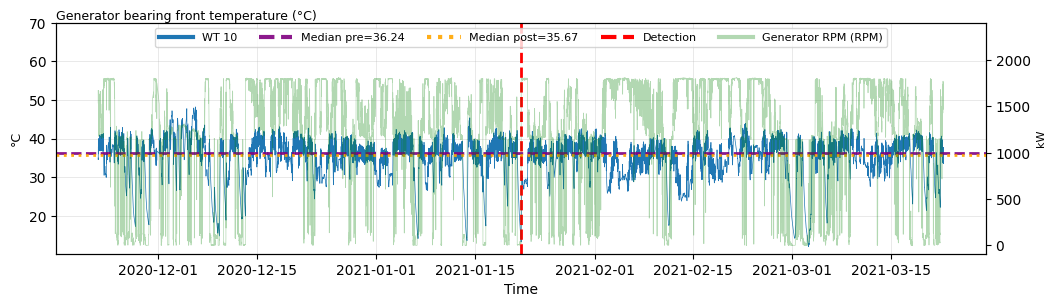

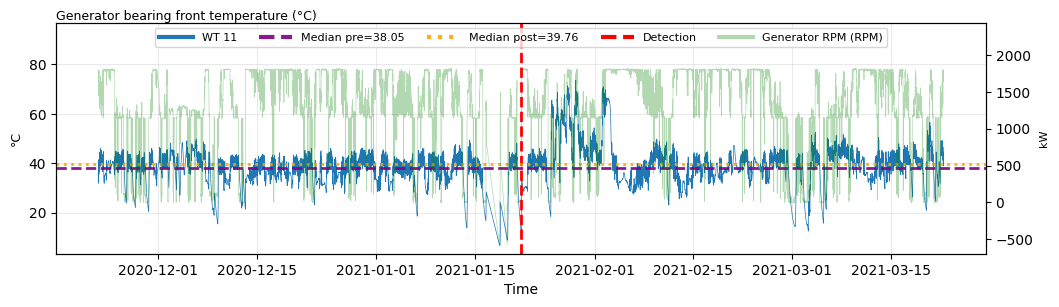

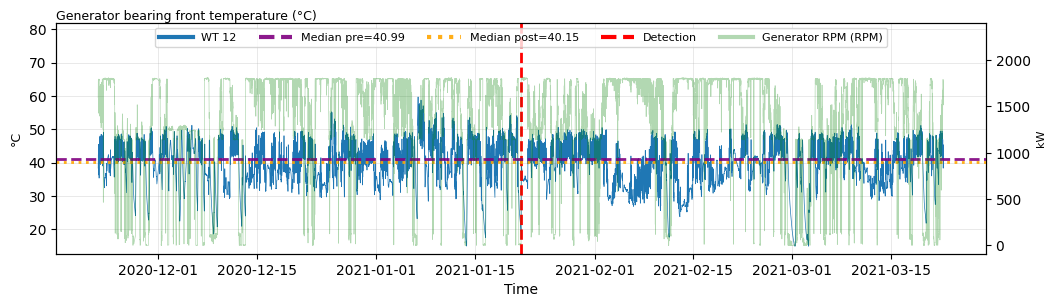

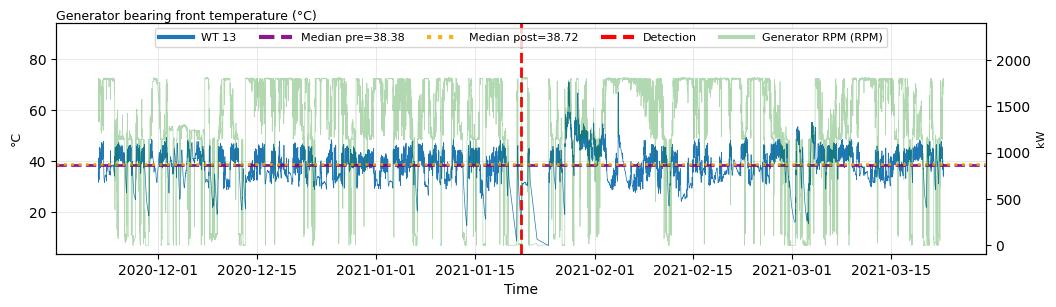

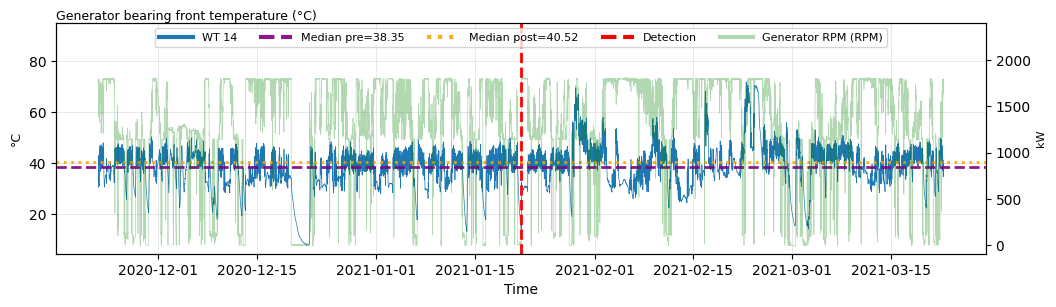

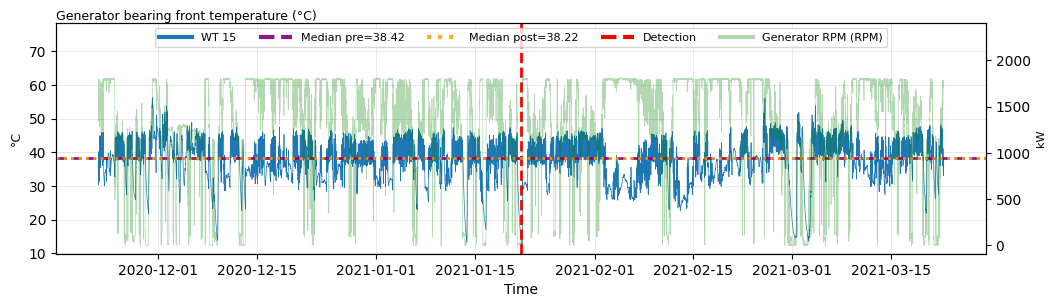

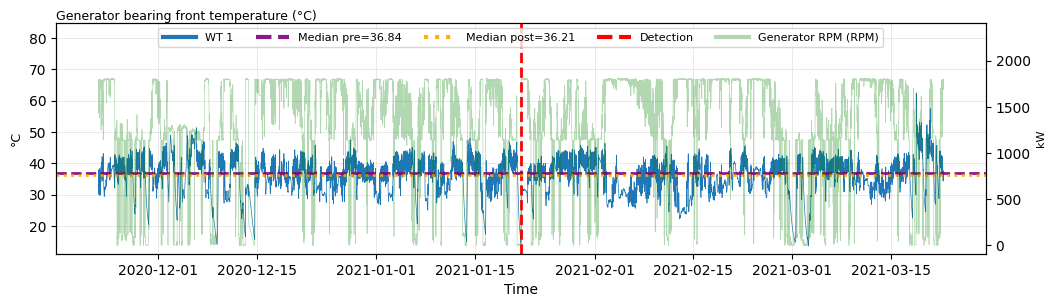

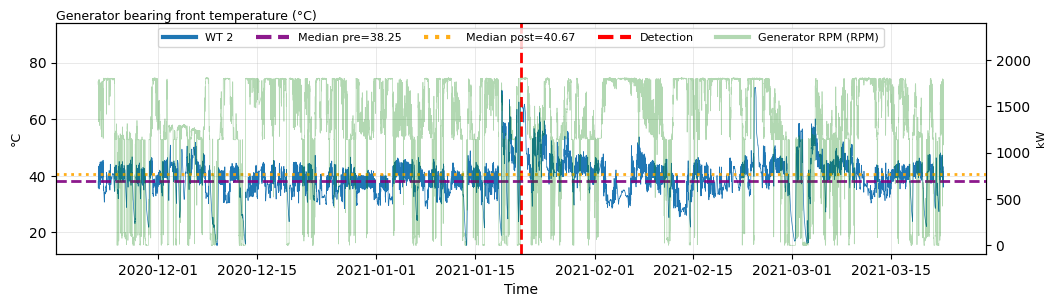

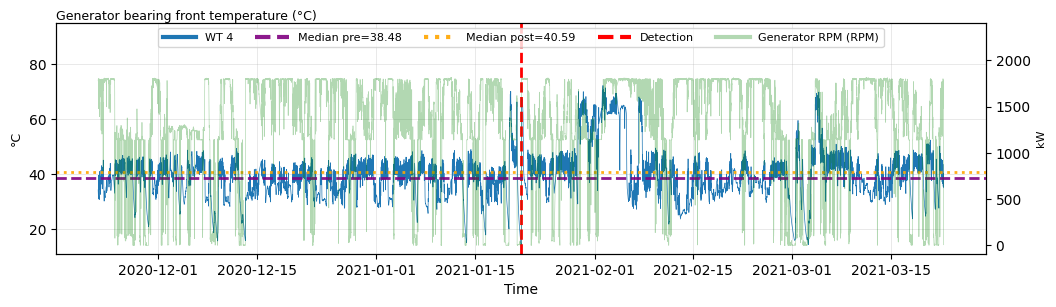

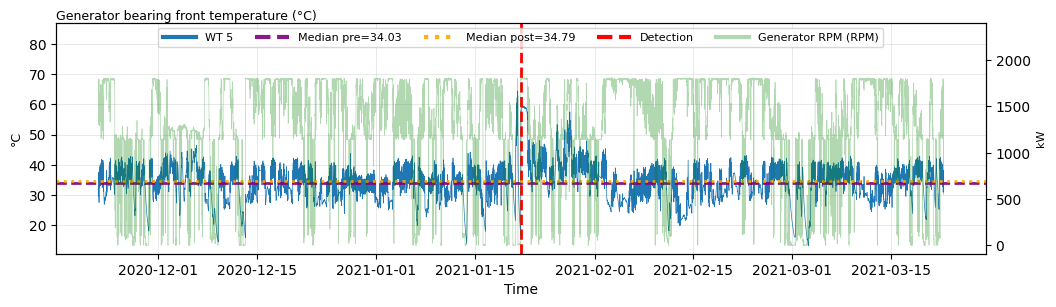

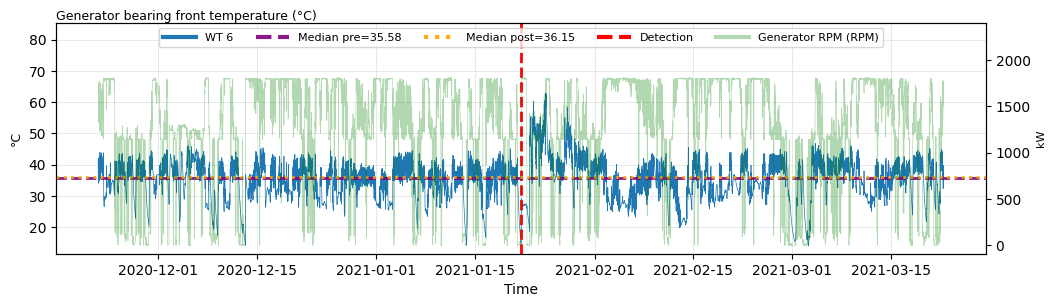

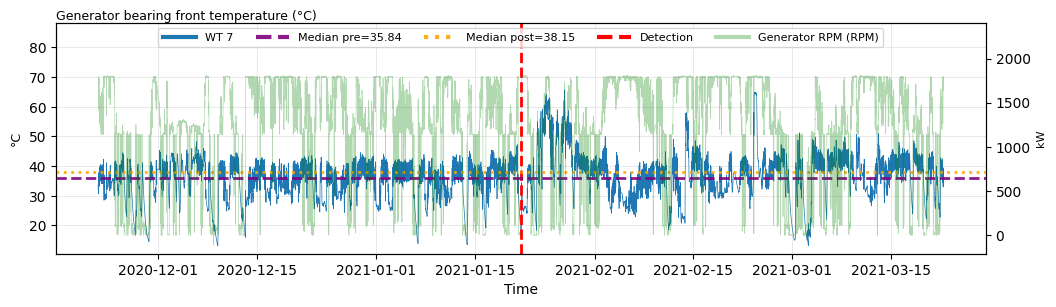

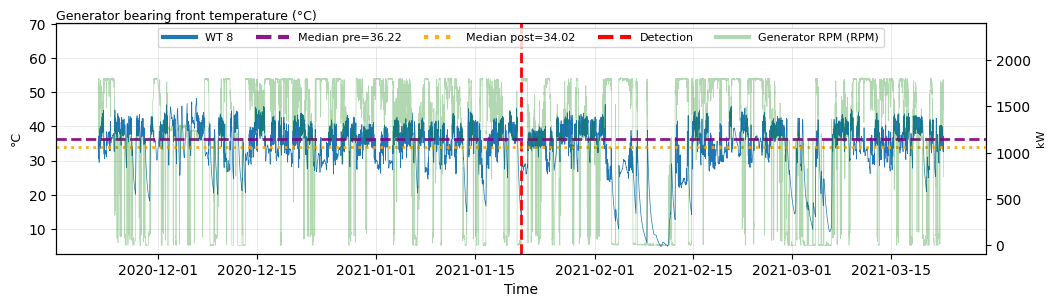

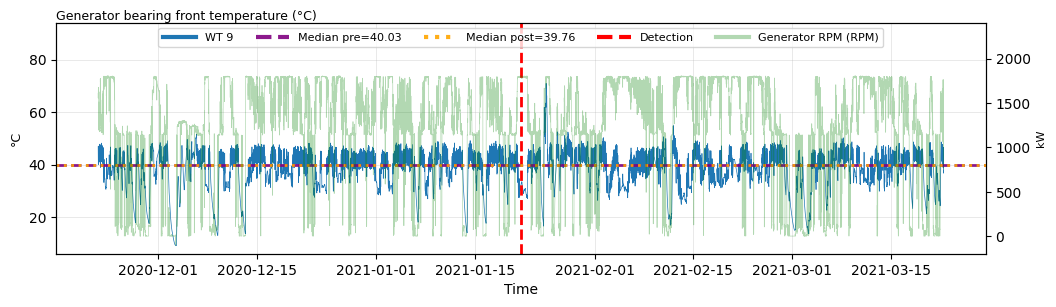

In [4]:
for file in fp:
    wt_df = pd.read_csv(file, parse_dates=[ic.TS_COL])
    wt = wt_df[ic.WT_ID].iloc[0]
    
    pp.plot_signals_compact(df=p2.drop_imputations(wt_df),
                            wt_id = wt,
                            signals=gen_sigs,
                            anomaly_spans= None,
                            fig_size=(12,3),
                            ts_mark=[detection_ts],
                            ts_range=(detection_ts- pd.Timedelta(days=60),detection_ts + pd.Timedelta(days=60)),
                            mean_linewidth=2.0,
                            plot_power= True,
                            power_col = 'Generator RPM (RPM)',
                            power_alpha = 0.3,
                            power_linewidth = 0.5,
                            sig_linewidth=0.5,
                            save_path=None,
                            )


In [5]:
fp = Path(ic.PATH_PENMANSHIEL).glob(f"Status_Logs_Complete_ID_*")

info: list[Tuple[any,pd.Timestamp]] = []
for file in fp:
    
    status_logs = pd.read_csv(file)

    status_logs["Timestamp start"] = pd.to_datetime(status_logs["Timestamp start"], errors="coerce")
    status_logs["Timestamp end"] = pd.to_datetime(status_logs["Timestamp end"], errors="coerce")

    delta = pd.Timedelta(days=3)
    det_start = detection_ts - delta
    det_end = detection_ts + delta

    filter = status_logs[(status_logs["Timestamp start"] <= det_end) & (status_logs["Timestamp end"] >= det_start)]

    #display(filter["Status"].unique())
    #print(detection_ts)

    a = filter[filter["Status"] == "Stop"]
    b =filter[filter["Status"] == "Warning"]

    stopwarn = pd.concat([a,b], axis=0)
    stopwarn = stopwarn.sort_values(by=["Timestamp start"], ascending=[True])
    stopwarn = stopwarn.drop(["Comment", "Custom contract category"],axis=1)

    states = ("Manual stop", "Overload generator fan")
    msgs = stopwarn[stopwarn["Message"].str.startswith(states, na=False)]

    display(msgs)
    wt = status_logs[ic.WT_ID].iloc[0]
    row = stopwarn[stopwarn["Message"].str.startswith("Manual stop", na=False)]
    #display(row)
    if not row.empty:
        
        ts = row["Timestamp end"].iloc[-1].floor("10min")
        info.append((wt,ts))

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category


C:\Users\admin\AppData\Local\Temp\ipykernel_6916\3086745433.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  status_logs["Timestamp end"] = pd.to_datetime(status_logs["Timestamp end"], errors="coerce")


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category
31593,2021-01-19 14:13:02,2021-01-19 14:15:29,00:02:27,Stop,20,Manual stop - on site,Manual stop (service) (9),Scheduled Maintenance,11,06 (Int) Scheduled Maintenance


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category
27227,2021-01-19 14:13:02,2021-01-19 14:15:29,00:02:27,Stop,20,Manual stop - on site,Manual stop (service) (9),Scheduled Maintenance,12,06 (Int) Scheduled Maintenance


...

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category
38374,2021-01-22 08:26:53,2021-01-22 17:49:55,09:23:02,Stop,20,Manual stop - on site,Manual stop (service) (9),Scheduled Maintenance,6,06 (Int) Scheduled Maintenance
38412,2021-01-22 18:00:07,2021-01-22 18:07:59,00:07:52,Stop,20,Manual stop - on site,Manual stop (service) (9),Scheduled Maintenance,6,06 (Int) Scheduled Maintenance


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category
42633,2021-01-23 08:28:24,2021-01-23 18:03:51,09:35:27,Stop,25,Manual stop without login,Manual stop (service) (9),Scheduled Maintenance,7,06 (Int) Scheduled Maintenance


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category


C:\Users\admin\AppData\Local\Temp\ipykernel_6916\3086745433.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  status_logs = pd.read_csv(file)


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Service contract category,IEC category,WT_ID,Global contract category
40045,2021-01-24 08:39:16,2021-01-24 09:32:39,00:53:23,Stop,20,Manual stop - on site,Manual stop (service) (9),Scheduled Maintenance,9,06 (Int) Scheduled Maintenance
40056,2021-01-24 09:39:09,2021-01-24 11:38:46,01:59:37,Warning,2550,Overload generator fan 1,Warnings (27),Forced outage,9,NaN
40057,2021-01-24 09:39:09,2021-01-24 11:38:45,01:59:36,Warning,2650,Overload generator fan 2,Warnings (27),Forced outage,9,NaN
40058,2021-01-24 09:39:09,2021-01-24 11:38:44,01:59:35,Warning,2655,Overload generator fan 3,Warnings (27),Forced outage,9,NaN


In [6]:
t: list = []

keep: list = [11,13,14,5,6,7,2]
for item in info:
    print(item)
    t.append(item[1])
   
t = np.array(t)
print(t.min())
print(t.max())

info = [(wt,ts) for wt,ts in info if wt in keep]

print(info)

(11, Timestamp('2021-01-19 14:10:00'))
(12, Timestamp('2021-01-19 14:10:00'))
(13, Timestamp('2021-01-18 13:10:00'))
(14, Timestamp('2021-01-18 12:30:00'))
(2, Timestamp('2021-01-18 18:00:00'))
(4, Timestamp('2021-01-19 18:10:00'))
(5, Timestamp('2021-01-20 09:50:00'))
(6, Timestamp('2021-01-22 18:00:00'))
(7, Timestamp('2021-01-23 18:00:00'))
(9, Timestamp('2021-01-24 09:30:00'))
2021-01-18 12:30:00
2021-01-24 09:30:00
[(11, Timestamp('2021-01-19 14:10:00')), (13, Timestamp('2021-01-18 13:10:00')), (14, Timestamp('2021-01-18 12:30:00')), (2, Timestamp('2021-01-18 18:00:00')), (5, Timestamp('2021-01-20 09:50:00')), (6, Timestamp('2021-01-22 18:00:00')), (7, Timestamp('2021-01-23 18:00:00'))]


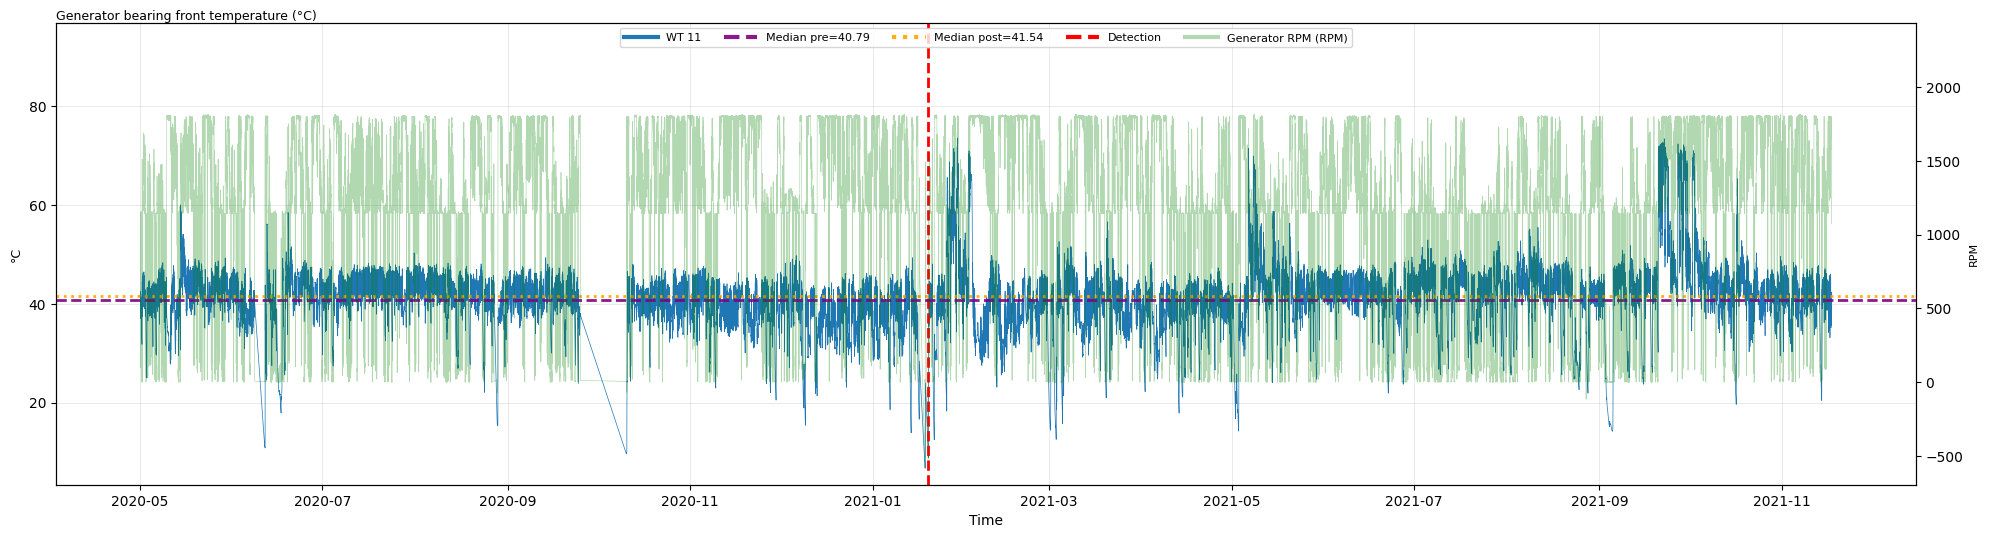

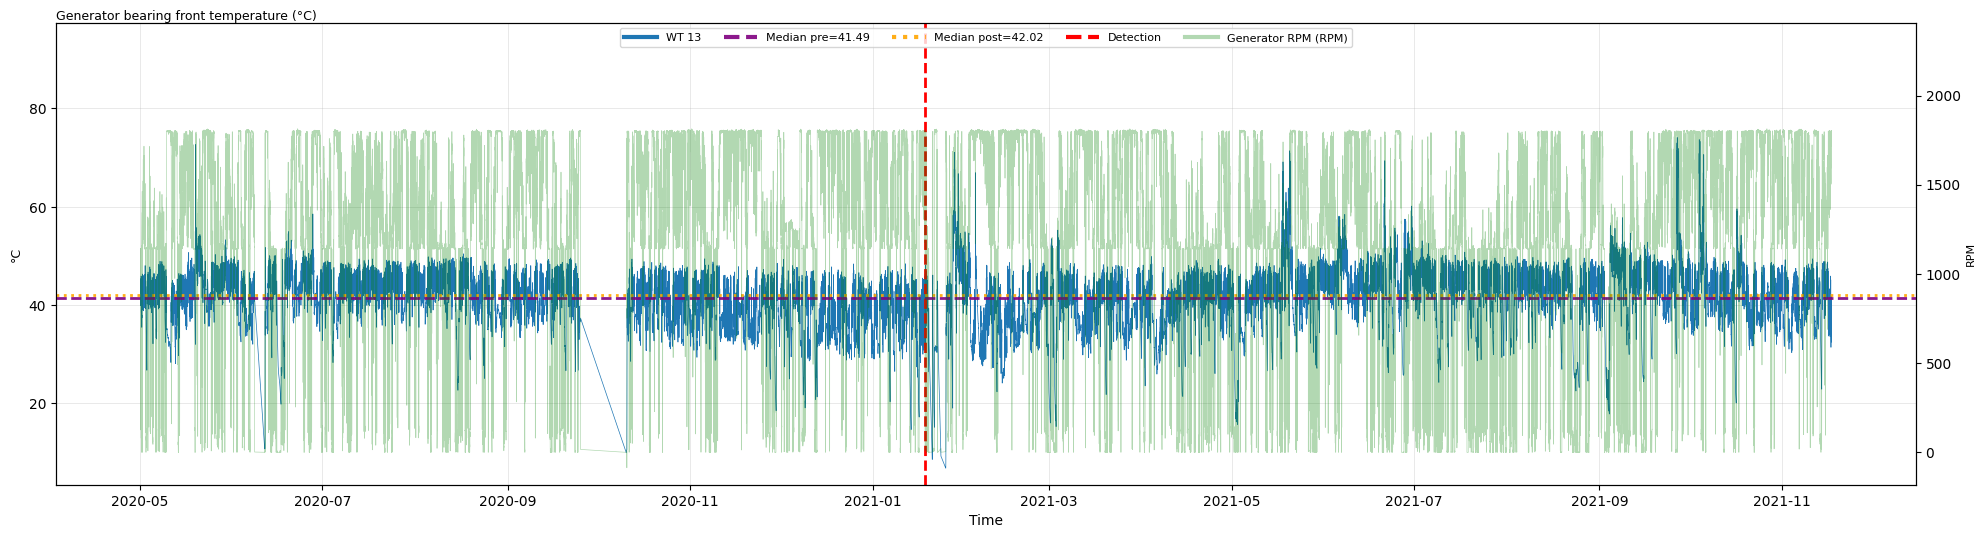

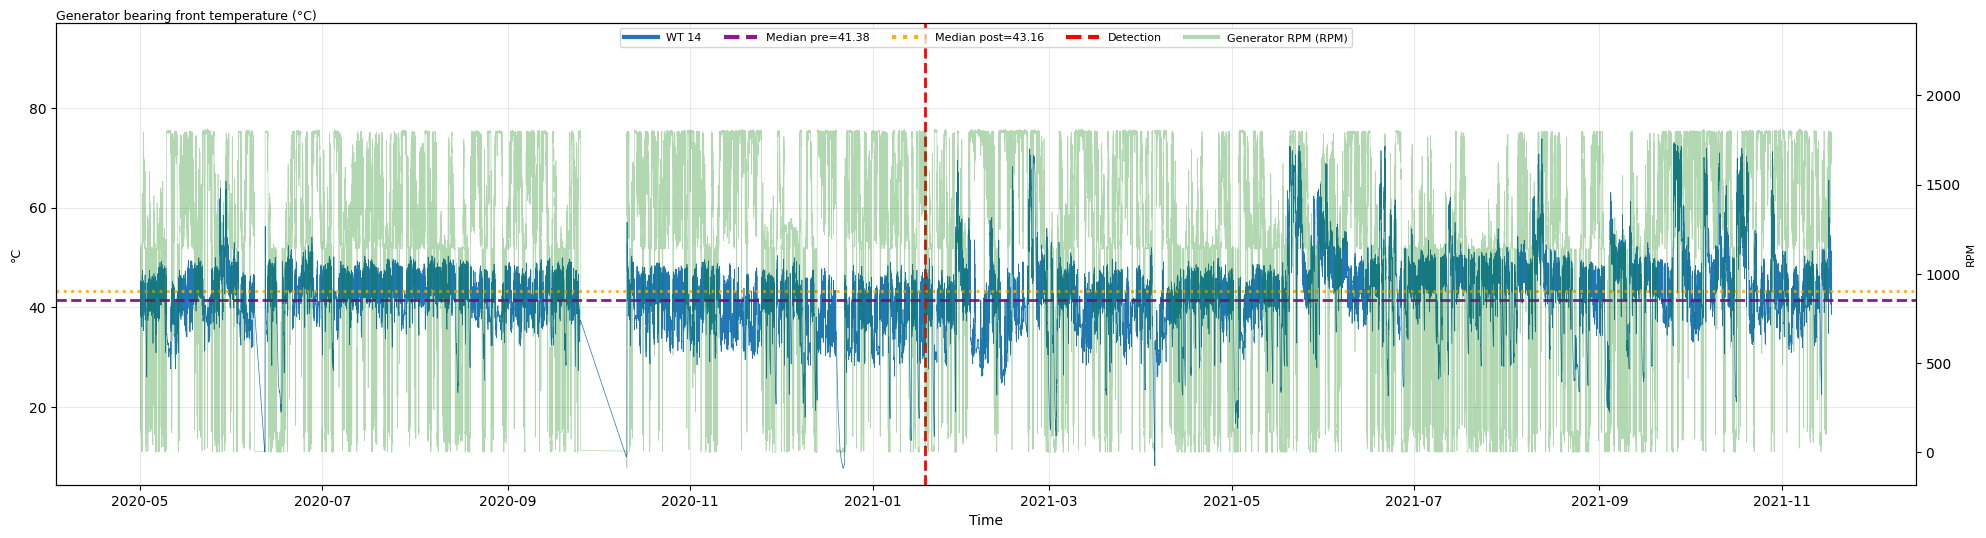

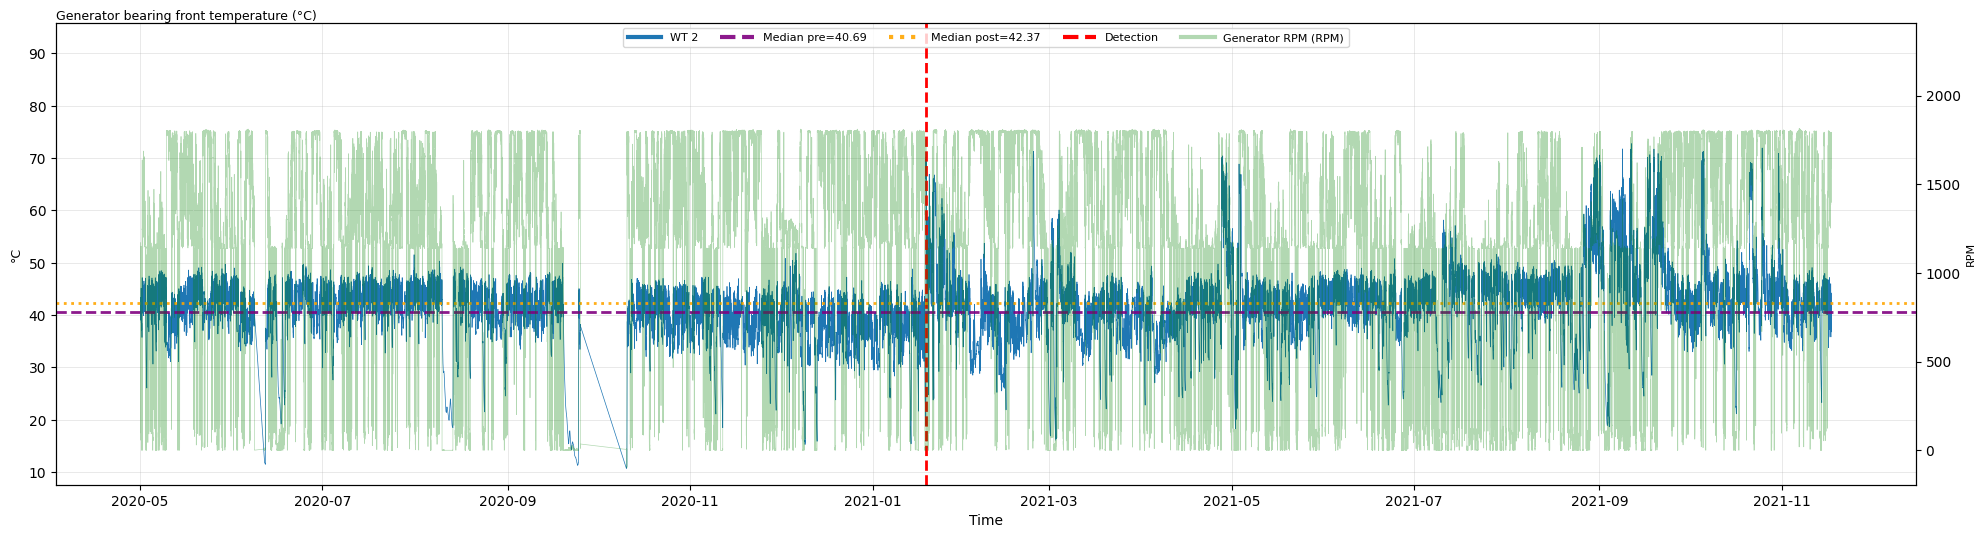

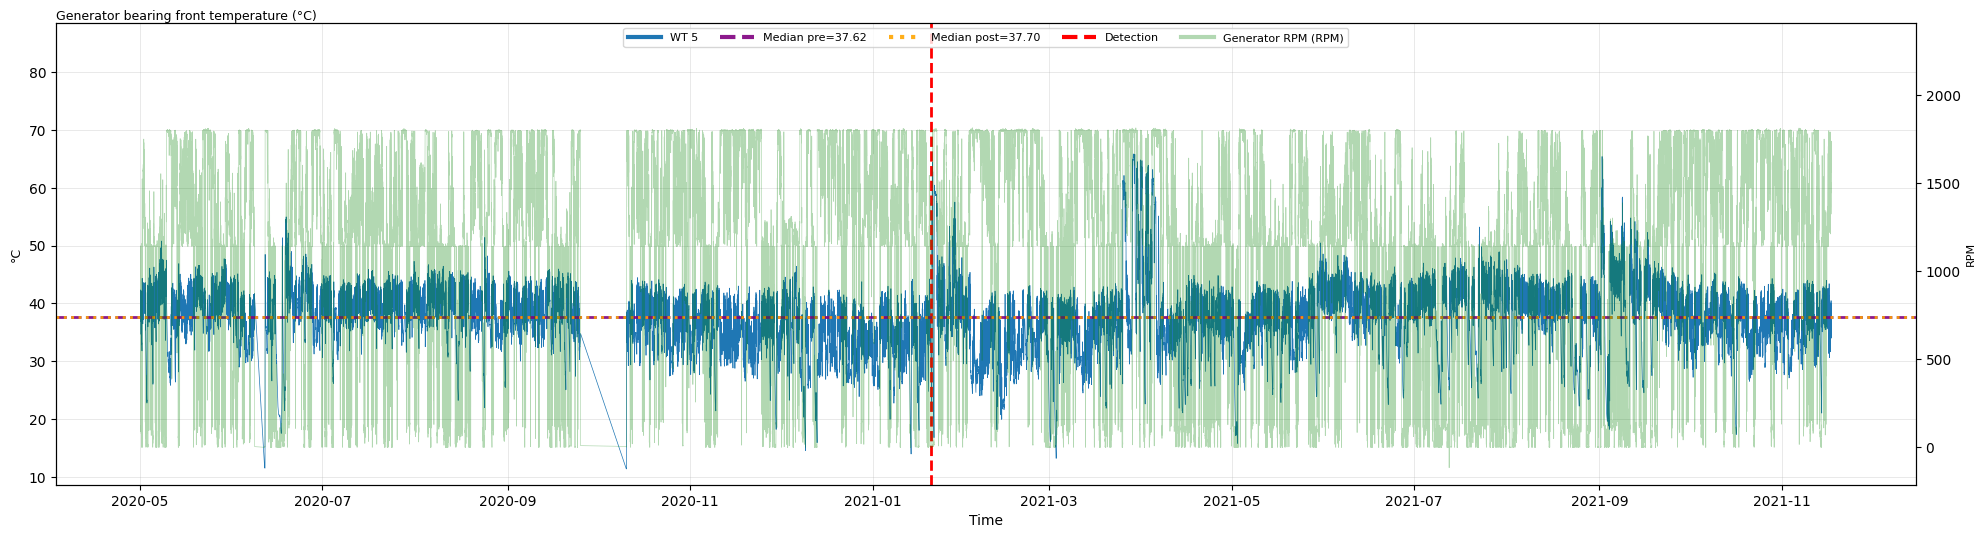

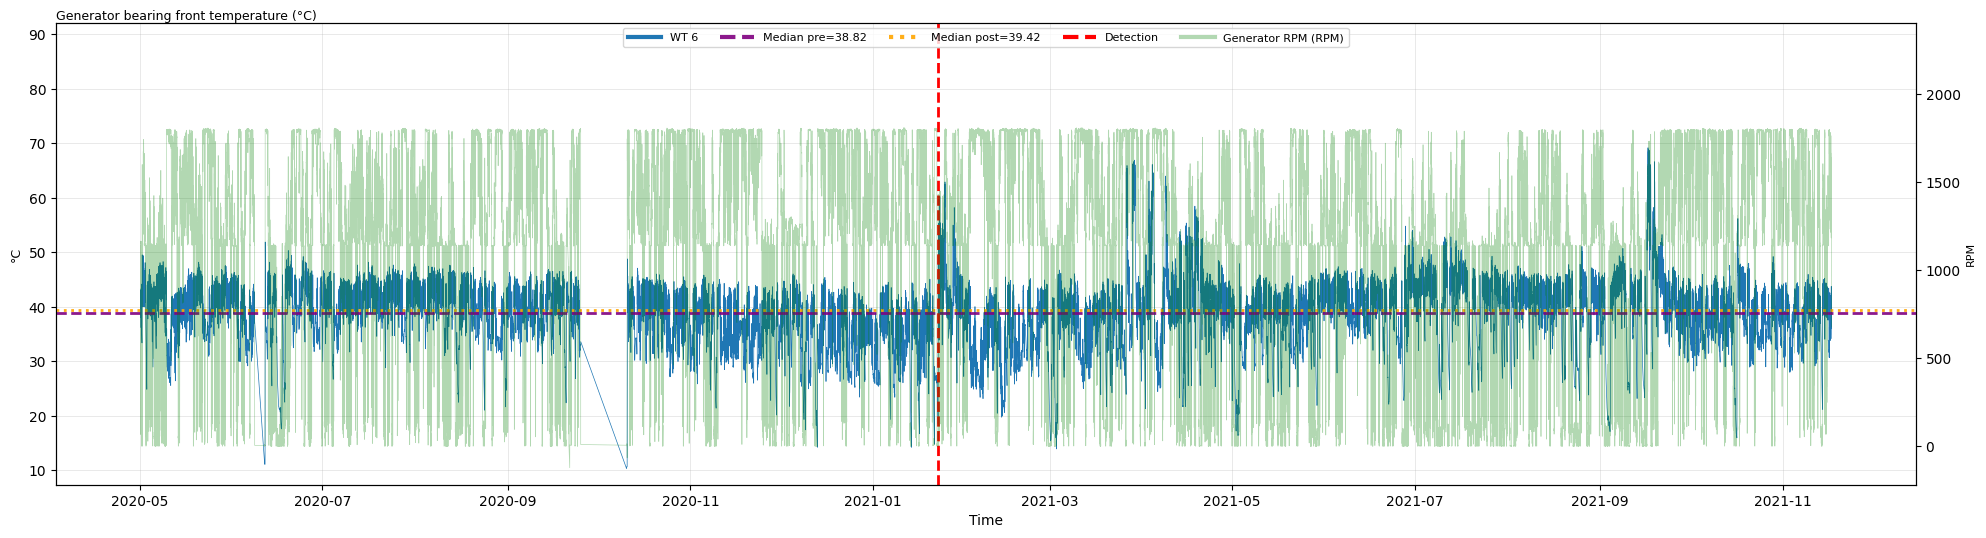

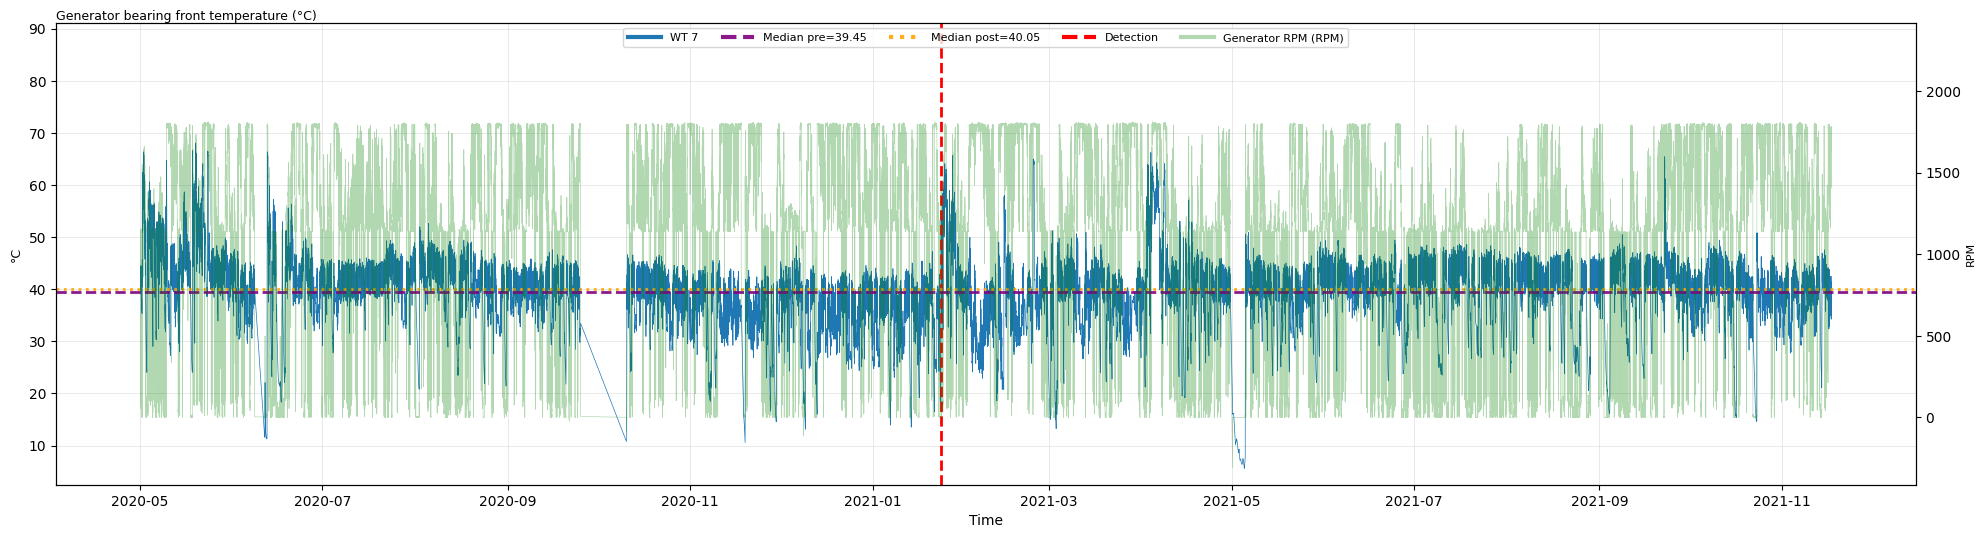

In [ ]:
for wt,ts in info:
    fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}*")
    wt_df = pd.read_csv(next(iter(fp)), parse_dates=[ic.TS_COL])
    wt_df = wt_df[(wt_df[ic.TS_COL] >= cfg_part2.test_start_time) & (wt_df[ic.TS_COL] <= cfg_part2.test_end_time)]
    offset = pd.Timedelta(days=300)
    pp.plot_signals_compact(df=p2.drop_imputations(wt_df),
                            wt_id = wt,
                            signals=gen_sigs,
                            anomaly_spans= None,
                            fig_size=(12,3),
                            ts_mark=[ts],
                            ts_mark_label="Maintenance"
                            ts_range=(detection_ts- offset,detection_ts + offset),
                            mean_linewidth=2.0,
                            plot_power= True,
                            power_col = "Generator RPM (RPM)",
                            power_col_ylabel="RPM",
                            power_alpha = 0.3,
                            power_linewidth = 0.5,
                            sig_linewidth=0.5,
                            save_path=None,
                            )

In [8]:
cpus = os.cpu_count() - 1
alpha = 0.05
def proc_col(col:str, wt_df, det_ts: pd.Timestamp, offset: pd.Timedelta, alpha:float):
    try:
        pr = ks.run_prewhitening_ks_pipeline(
        df=wt_df,
        col=col,
        ts_det=det_ts,
        offset=offset,
        )
        return {"ok": True, "col": col, "res": pr, "err": None}
    except Exception as e:
        return {"ok": False, "col": col, "res": None, "err": e}
    




In [9]:
total_results:list = []
for wt, ts in info:
    fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}*")
    wt_df = pd.read_csv(next(iter(fp)), parse_dates=[ic.TS_COL])
    wt_df = p2.drop_imputations(wt_df)
    jobs = Parallel(n_jobs=cpus, backend="loky")(delayed(proc_col)(col,wt_df,ts, pd.Timedelta(days=730),alpha=alpha) for col in tqdm(gen_sigs))
    
    for j in jobs:
        if j["ok"] == False:
            raise ValueError(f"Error occured")

    pipeline_results = [j["res"] for j in jobs]
    total_results.extend(pipeline_results)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
df_total = ks.report_total_many(total_results)
df_total = df_total.sort_values(by=["cliff's delta (raw)"], ascending=[False])

In [11]:

display(df_total.head(30))

,wt id,ts center,signal,∆ median (raw),∆ ln σ (raw),cliff's delta (raw)
2,14,2021-01-18 12:30:00,Generator bearing front temperature (°C),1.192,0.253,0.121
3,2,2021-01-18 18:00:00,Generator bearing front temperature (°C),0.812,0.140,0.098
0,11,2021-01-19 14:10:00,Generator bearing front temperature (°C),0.775,0.367,0.085
6,7,2021-01-23 18:00:00,Generator bearing front temperature (°C),0.525,0.110,0.042
1,13,2021-01-18 13:10:00,Generator bearing front temperature (°C),0.375,0.092,0.036
4,5,2021-01-20 09:50:00,Generator bearing front temperature (°C),0.203,0.279,0.023
5,6,2021-01-22 18:00:00,Generator bearing front temperature (°C),-0.042,0.293,-0.014


In [12]:
df_total.to_csv(ic.PATH_PART2_KS_TEST / "wt2_farmwide_test.csv", index=False)

ltx6 = df_total.to_latex(index=False,      escape=True, float_format="%.3f")

with open(ic.PATH_PRINTS/"p2_31_farmwide.tex", "w", encoding="utf-8") as f:
    f.write(ltx6)